In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Connect to SQLite database file
conn = sqlite3.connect("sales_data.db")
cursor = conn.cursor()

# Create a sales table
cursor.execute('''
    CREATE TABLE IF NOT EXISTS sales (
        transaction_id TEXT,
        product TEXT,
        quantity INTEGER,
        price REAL
    )
''')

# Sample sales data
sample_data = [
    ("TXN_001", "Coffee", 3, 2.5),
    ("TXN_002", "Cake", 2, 3.0),
    ("TXN_003", "Cookie", 5, 1.0),
    ("TXN_004", "Smoothie", 1, 4.0),
    ("TXN_005", "Coffee", 2, 2.5),
    ("TXN_006", "Cake", 1, 3.0),
    ("TXN_007", "Cookie", 2, 1.0)
]

# Insert data
cursor.executemany("INSERT INTO sales VALUES (?, ?, ?, ?)", sample_data)
conn.commit()


In [2]:
# SQL to calculate total quantity and revenue per product
query = """
SELECT 
    product, 
    SUM(quantity) AS total_qty, 
    SUM(quantity * price) AS revenue
FROM sales
GROUP BY product
"""

# Load into DataFrame
df = pd.read_sql_query(query, conn)

# Print result
print("Sales Summary:")
print(df)


Sales Summary:
    product  total_qty  revenue
0      Cake          3      9.0
1    Coffee          5     12.5
2    Cookie          7      7.0
3  Smoothie          1      4.0


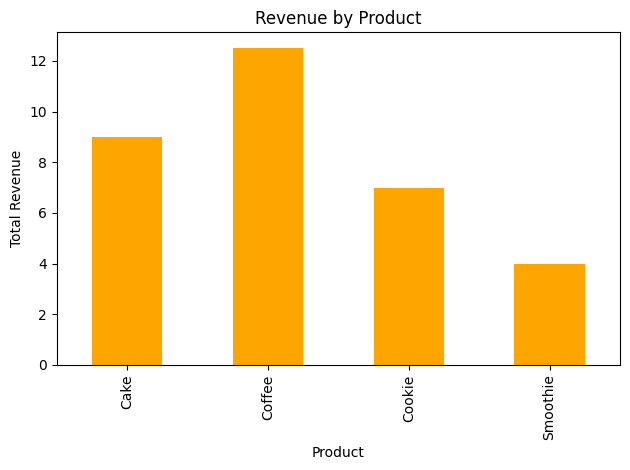

In [3]:
# Plot revenue by product
df.plot(kind='bar', x='product', y='revenue', color='orange', legend=False)
plt.title('Revenue by Product')
plt.xlabel('Product')
plt.ylabel('Total Revenue')
plt.tight_layout()
plt.savefig("sales_chart.png")  # Save chart.png
plt.show()
